# Systematics 2D Dev

Load the test FLT, extract the ROI, and plot full frame and ROI with cbrt stretch. Includes a row fit that respects DQ flags and ROI limits.

In [1]:
from pathlib import Path

import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt

# Use interactive backend in Jupyter
%matplotlib widget

import sys
sys.path.append('..')
from models import airglow_broadened_boxcar_row

In [2]:
# Configuration
flt_path = Path("../test-data/of9b05010_flt.fits")
roi_x0, roi_x1 = 380, 420
roi_y0, roi_y1 = 185, 205

# DQ flags to mask (bitwise)
dq_flags = [1, 2, 4, 16, 32, 256, 512, 8192]
dq_mask_value = int(np.sum(dq_flags))

In [3]:
# Load FLT and extract ROI
with fits.open(flt_path) as hdul:
    sci = hdul["SCI"].data.astype(float)
    dq = hdul["DQ"].data.astype(int) if "DQ" in hdul else None

roi = sci[roi_y0:roi_y1, roi_x0:roi_x1]
print("Full shape:", sci.shape, "ROI shape:", roi.shape)

Full shape: (1024, 1024) ROI shape: (20, 40)


In [ ]:
# Plot full frame (cbrt stretch)
full_display = np.cbrt(sci)

plt.figure(figsize=(4,3))
plt.imshow(full_display, origin="lower", aspect="auto")
plt.colorbar(label="Counts (cbrt)")
plt.title("FLT full frame (cbrt)")
plt.tight_layout()

In [ ]:
# Plot ROI (cbrt stretch)
roi_display = np.cbrt(roi)

plt.figure(figsize=(3,2))
plt.imshow(roi_display, origin="lower", aspect="auto")
plt.colorbar(label="Counts (cbrt)")
plt.title("FLT ROI (cbrt)")
plt.tight_layout()

In [ ]:
# Define parameters for the airglow model

xgrid = np.arange(0, 100)

# Define the airglow model parameters
centroid = 50
width = 30
fwhm_g = 10
fwhm_l = 0.1
amplitude = 10

# Compute the airglow model
model = airglow_broadened_boxcar_row(xgrid, centroid, width, amplitude, fwhm_g, fwhm_l)

# Plot the model
plt.figure(figsize=(4,3))
plt.plot(xgrid, model)

Fit params: [397.           6.00000001  49.68929167   1.2057926    0.53306713]
N pixels masked: 0


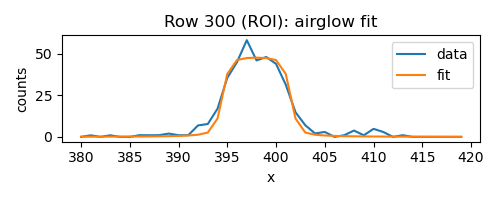

In [5]:
# Fit a selected row using the helper functions
import models

row_index = 300  # pick a row in the full frame
row = sci[row_index]
x_grid = np.arange(len(row))

# Build DQ row if available
if dq is not None:
    dq_row = dq[row_index]
else:
    dq_row = None

fit, params, keep = models.fit_airglow_row(
    row,
    x_grid,
    roi_x0,
    roi_x1,
    dq_row=dq_row,
    dq_mask_value=dq_mask_value,
    lsf_kernel=None,
    init=None,
)

x_roi = x_grid[roi_x0:roi_x1]
row_roi = row[roi_x0:roi_x1]

print("Fit params:", params)

plt.figure(figsize=(5,2))
plt.plot(x_roi, row_roi, label="data")
plt.plot(x_roi, fit, label="fit")
plt.xlabel("x")
plt.ylabel("counts")
plt.title(f"Row {row_index} (ROI): airglow fit")
plt.legend()
plt.tight_layout()

print('N pixels masked:', np.sum(~keep))

In [6]:
# Fit airglow model across ROI rows
from importlib import reload
reload(models)

roi_y0 = 250
roi_y1 = 300

rows = sci[roi_y0:roi_y1]
row_indices = np.arange(roi_y0, roi_y1)
if dq is not None:
    dq_rows = dq[roi_y0:roi_y1]
else:
    dq_rows = None

x_grid = np.arange(sci.shape[1])

fit_results = models.fit_airglow_rows(
    rows,
    x_grid,
    roi_x0,
    roi_x1,
    row_indices=row_indices,
    dq_rows=dq_rows,
    dq_mask_value=dq_mask_value,
    lsf_kernel=None,
    init=None,
)

roi_fit = fit_results["fits"]
print("Fitted rows:", roi_fit.shape)

Fitted rows: (50, 40)


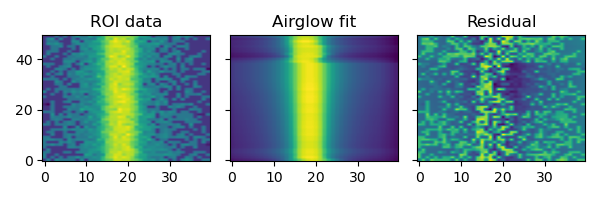

In [9]:
# Plot original ROI, fit image, and difference
roi_data = sci[roi_y0:roi_y1, roi_x0:roi_x1]
residual = roi_data - roi_fit

fig, axes = plt.subplots(1,3, figsize=(6,2), sharex=True, sharey=True)

for ax, img, title in zip(
    axes,
    [roi_data, roi_fit, residual],
    ["ROI data", "Airglow fit", "Residual"],
):
    disp = np.cbrt(img)
    ax.imshow(disp, origin="lower", aspect="auto")
    ax.set_title(title)

plt.tight_layout()

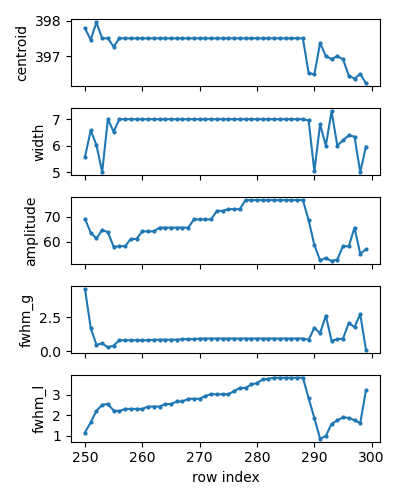

In [10]:
# Plot fit parameters vs row index
params = fit_results["params"]
labels = ["centroid", "width", "amplitude", "fwhm_g", "fwhm_l"]

fig, axes = plt.subplots(len(labels), 1, figsize=(4,5), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(row_indices, params[:, i], marker="o", ms=2)
    ax.set_ylabel(label)
axes[-1].set_xlabel("row index")
plt.tight_layout()

In [11]:
# Fit again using median params from first run as seed
median_params = np.nanmedian(fit_results["params"], axis=0)

fit_results_seeded = models.fit_airglow_rows(
    rows,
    x_grid,
    roi_x0,
    roi_x1,
    row_indices=row_indices,
    dq_rows=dq_rows,
    dq_mask_value=dq_mask_value,
    lsf_kernel=None,
    init=median_params,
)

roi_fit_seeded = fit_results_seeded["fits"]
print("Seeded fit rows:", roi_fit_seeded.shape)
print("Median seed params:", median_params)

Seeded fit rows: (50, 40)
Median seed params: [397.49999999   6.99999998  65.58398376   0.93923675   2.60630627]


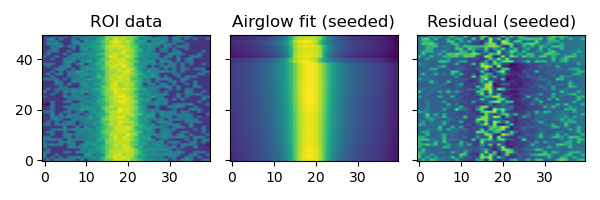

In [12]:
# Plot original ROI, seeded-fit image, and difference
roi_data = sci[roi_y0:roi_y1, roi_x0:roi_x1]
residual_seeded = roi_data - roi_fit_seeded

fig, axes = plt.subplots(1, 3, figsize=(6,2), sharex=True, sharey=True)

for ax, img, title in zip(
    axes,
    [roi_data, roi_fit_seeded, residual_seeded],
    ["ROI data", "Airglow fit (seeded)", "Residual (seeded)"],
):
    disp = np.cbrt(img)
    ax.imshow(disp, origin="lower", aspect="auto")
    ax.set_title(title)
plt.tight_layout()

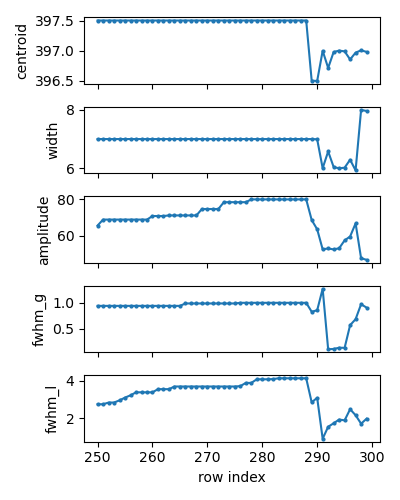

In [13]:
# Plot seeded-fit parameters vs row index
params_seeded = fit_results_seeded["params"]
labels = ["centroid", "width", "amplitude", "fwhm_g", "fwhm_l"]

fig, axes = plt.subplots(len(labels), 1, figsize=(4,5), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(row_indices, params_seeded[:, i], marker="o", ms=2)
    ax.set_ylabel(label)
axes[-1].set_xlabel("row index")
plt.tight_layout()

In [ ]:
# try fitting a smaller range to see if the end still goes wild

In [35]:
roi_y0 = 220
roi_y1 = 320

rows = sci[roi_y0:roi_y1]
row_indices = np.arange(roi_y0, roi_y1)


# Fit again using median params from first run as seed
median_params = np.nanmedian(fit_results["params"], axis=0)

fit_results_seeded = models.fit_airglow_rows(
    rows,
    x_grid,
    roi_x0,
    roi_x1,
    row_indices=row_indices,
    dq_rows=dq_rows,
    dq_mask_value=dq_mask_value,
    lsf_kernel=None,
    init=median_params,
)

roi_fit_seeded = fit_results_seeded["fits"]
print("Seeded fit rows:", roi_fit_seeded.shape)
print("Median seed params:", median_params)

Seeded fit rows: (100, 40)
Median seed params: [397.49999999   6.99999998  65.58398376   0.93923675   2.60630627]


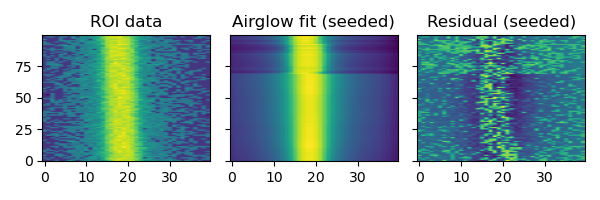

In [36]:
# Plot original ROI, seeded-fit image, and difference
roi_data = sci[roi_y0:roi_y1, roi_x0:roi_x1]
residual_seeded = roi_data - roi_fit_seeded

fig, axes = plt.subplots(1,3, figsize=(6,2), sharex=True, sharey=True)

for ax, img, title in zip(
    axes,
    [roi_data, roi_fit_seeded, residual_seeded],
    ["ROI data", "Airglow fit (seeded)", "Residual (seeded)"],
):
    disp = np.cbrt(img)
    ax.imshow(disp, origin="lower", aspect="auto")
    ax.set_title(title)
plt.tight_layout()

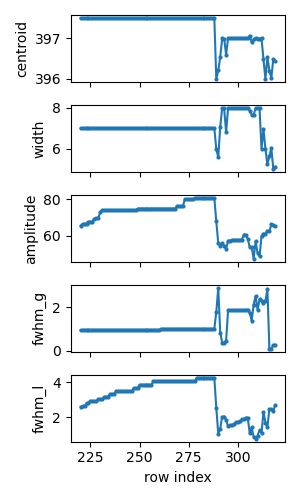

In [37]:
# Plot seeded-fit parameters vs row index
params_seeded = fit_results_seeded["params"]
labels = ["centroid", "width", "amplitude", "fwhm_g", "fwhm_l"]

fig, axes = plt.subplots(len(labels), 1, figsize=(3, 5), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(row_indices, params_seeded[:, i], marker="o", ms=2)
    ax.set_ylabel(label)
axes[-1].set_xlabel("row index")
plt.tight_layout()

end does not go wild, so I don't think that's an artifact of the fitting. the original wildness of the start, however, was

OG integral: 0.12551705765976967
Resampled integral: 1.0


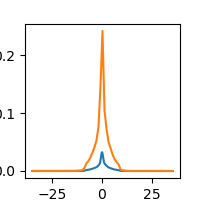

In [17]:
# Fit a selected row using the helper functions + STIS LSF
import psf_lsf

lsf_offsets, lsf_vals = psf_lsf.load_lsf(name="G140M_1200", aperture="52x0.2")
lsf_grid, lsf_kernel = psf_lsf.resample_lsf(lsf_offsets, lsf_vals, step=1.0)

plt.figure(figsize=(2,2))
plt.plot(lsf_offsets, lsf_vals)
plt.plot(lsf_grid, lsf_kernel)

print('OG integral:', np.trapz(lsf_vals, lsf_offsets))
print('Resampled integral:', np.trapz(lsf_kernel, lsf_grid))


Fit params (LSF): [3.96997677e+02 7.99480274e+00 6.11358205e+01 5.17123931e-01
 1.00002750e-05]


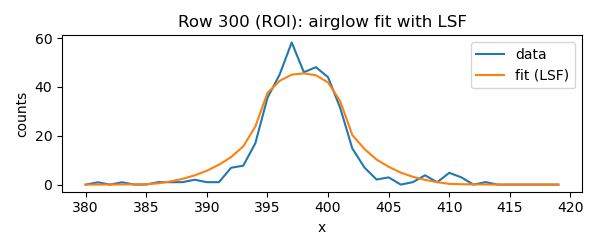

In [18]:
reload(models)

fit_lsf, params_lsf, keep_lsf = models.fit_airglow_row(
    row,
    x_grid,
    roi_x0,
    roi_x1,
    dq_row=dq_row,
    dq_mask_value=dq_mask_value,
    lsf_kernel=lsf_kernel,
    init=None,
)

print("Fit params (LSF):", params_lsf)

plt.figure(figsize=(6,2.5))
plt.plot(x_roi, row_roi, label="data")
plt.plot(x_roi, fit_lsf, label="fit (LSF)")
plt.xlabel("x")
plt.ylabel("counts")
plt.title(f"Row {row_index} (ROI): airglow fit with LSF")
plt.legend()
plt.tight_layout()

In [32]:
# Fit airglow model across ROI rows (with LSF)
import psf_lsf

roi_y0 = 220
roi_y1 = 320

rows = sci[roi_y0:roi_y1]
row_indices = np.arange(roi_y0, roi_y1)
dq_rows = dq[roi_y0:roi_y1]

lsf_offsets, lsf_vals = psf_lsf.load_lsf(name="G140M_1200", aperture="52x0.2")
_, lsf_kernel = psf_lsf.resample_lsf(lsf_offsets, lsf_vals, step=1.0)

fit_results_lsf = models.fit_airglow_rows(
    rows,
    x_grid,
    roi_x0,
    roi_x1,
    row_indices=row_indices,
    dq_rows=dq_rows,
    dq_mask_value=dq_mask_value,
    lsf_kernel=lsf_kernel,
    init=None,
)

roi_fit_lsf = fit_results_lsf["fits"]
print("Fitted rows (LSF):", roi_fit_lsf.shape)

Fitted rows (LSF): (100, 40)


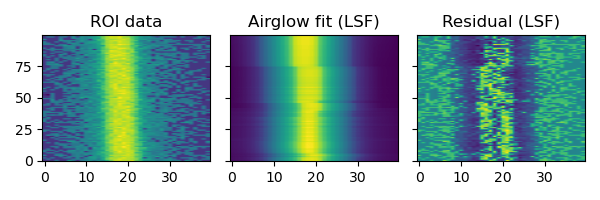

In [33]:
# Plot original ROI, LSF-fit image, and difference
rows = sci[roi_y0:roi_y1]
row_indices = np.arange(roi_y0, roi_y1)

roi_data = sci[roi_y0:roi_y1, roi_x0:roi_x1]
residual_lsf = roi_data - roi_fit_lsf

fig, axes = plt.subplots(1,3, figsize=(6,2), sharex=True, sharey=True)

for ax, img, title in zip(
    axes,
    [roi_data, roi_fit_lsf, residual_lsf],
    ["ROI data", "Airglow fit (LSF)", "Residual (LSF)"],
):
    disp = np.cbrt(img)
    ax.imshow(disp, origin="lower", aspect="auto")
    ax.set_title(title)

plt.tight_layout()

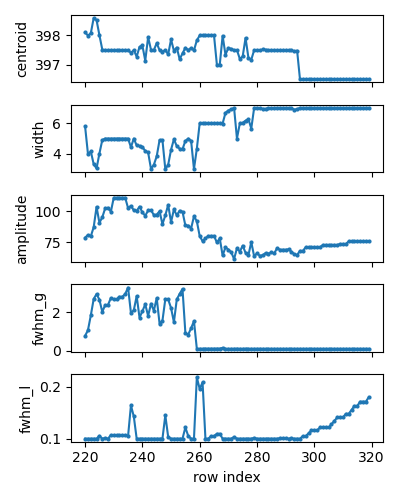

In [38]:
# Plot LSF-fit parameters vs row index
params_lsf = fit_results_lsf["params"]
labels = ["centroid", "width", "amplitude", "fwhm_g", "fwhm_l"]

fig, axes = plt.subplots(len(labels), 1, figsize=(4,5), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.plot(row_indices, params_lsf[:, i], marker="o", ms=2)
    ax.set_ylabel(label)
axes[-1].set_xlabel("row index")
plt.tight_layout()

In [66]:
# GP fit for airglow parameters vs row index
# Use row-by-row fits (non-LSF) from fit_results
reload(models)

row_x = row_indices
params = fit_results_lsf["params"]
centroid = params[:, 0]
width = params[:, 1]
amplitude = params[:, 2]

median_fwhm_g = np.nanmedian(params[:, 3])
median_fwhm_l = np.nanmedian(params[:, 4])

# you kinda have to set the smoothing manually, because its affected by signal amplitude
smoothing_centroid = 10.0  # larger = smoother
smoothing_width = 10.0
smoothing_amplitude = 10.0

_, centroid_gp = models.fit_gp_1d(row_x, centroid, smoothing=smoothing_centroid, white_noise=1e-3, fit_white_noise=False)
_, width_gp = models.fit_gp_1d(row_x, width, smoothing=smoothing_width, white_noise=0.1, fit_white_noise=False)
_, amplitude_gp = models.fit_gp_1d(row_x, amplitude, smoothing=smoothing_amplitude, white_noise=0.1, fit_white_noise=False)

print("Median fwhm_g:", median_fwhm_g)
print("Median fwhm_l:", median_fwhm_l)

Median fwhm_g: 0.10413717184067617
Median fwhm_l: 0.10080984117257144


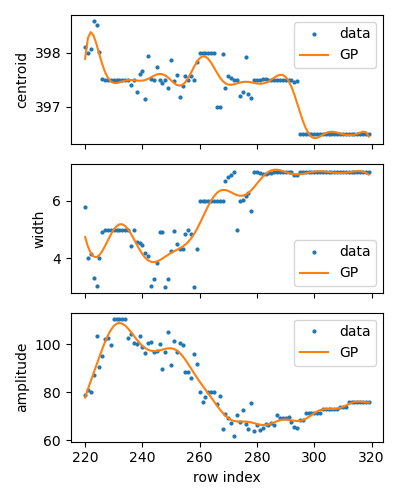

In [67]:
# Plot GP fits vs raw parameters
fig, axes = plt.subplots(3, 1, figsize=(4, 5), sharex=True)

axes[0].plot(row_x, centroid, "o", ms=2, label="data")
axes[0].plot(row_x, centroid_gp, "-", label="GP")
axes[0].set_ylabel("centroid")
axes[0].legend()

axes[1].plot(row_x, width, "o", ms=2, label="data")
axes[1].plot(row_x, width_gp, "-", label="GP")
axes[1].set_ylabel("width")
axes[1].legend()

axes[2].plot(row_x, amplitude, "o", ms=2, label="data")
axes[2].plot(row_x, amplitude_gp, "-", label="GP")
axes[2].set_ylabel("amplitude")
axes[2].set_xlabel("row index")
axes[2].legend()

plt.tight_layout()

In [ ]:
# Optional: set different smoothing per parameter
smoothing_centroid = 3.0  # larger = smoother
smoothing_width = 3.0
smoothing_amplitude = 3.0

_, centroid_gp, _ = models.fit_gp_1d(
    row_x,
    centroid,
    smoothing=smoothing_centroid,
    fit_white_noise=True,
)
_, width_gp, _ = models.fit_gp_1d(
    row_x,
    width,
    smoothing=smoothing_width,
    fit_white_noise=True,
)
_, amplitude_gp, _ = models.fit_gp_1d(
    row_x,
    amplitude,
    smoothing=smoothing_amplitude,
    fit_white_noise=True,
)

In [ ]:
# EMD on centroid/width/amplitude series
max_imf = 5

centroid_imfs, centroid_res = models.emd_decompose_1d(centroid, max_imf=max_imf)
width_imfs, width_res = models.emd_decompose_1d(width, max_imf=max_imf)
amplitude_imfs, amplitude_res = models.emd_decompose_1d(amplitude, max_imf=max_imf)

series = [
    ("centroid", centroid, centroid_imfs, centroid_res),
    ("width", width, width_imfs, width_res),
    ("amplitude", amplitude, amplitude_imfs, amplitude_res),
]

for name, data, imfs, res in series:
    n_imfs = imfs.shape[0] if imfs.size else 0
    fig, axes = plt.subplots(n_imfs + 2, 1, figsize=(4, 2 * (n_imfs + 2)), sharex=True)
    axes[0].plot(row_x, data)
    axes[0].set_ylabel(f"{name}")
    axes[0].set_title(f"EMD: {name}")

    for i in range(n_imfs):
        axes[i + 1].plot(row_x, imfs[i])
        axes[i + 1].set_ylabel(f"IMF {i + 1}")

    axes[-1].plot(row_x, res)
    axes[-1].set_ylabel("residual")
    axes[-1].set_xlabel("row index")
    plt.tight_layout()